<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/> 

# Exploratory Data Analysis
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

## Programmes

* Data science accelerator - Workshop 2.1

## Content

### Introductions

#### Purpose: What is the aim of the content?

In this workshop you will practice exploring data with `pandas`, visualising data with `seaborn` and discuss data storytelling, in order to gain the confidence to start making your own data reports and data stories in Python.

#### Objectives: What will I learn?

* Build professional data wrangling pipelines using method chaining
* Apply lambda functions for concise column transformations
* Use groupby and aggregation to summarise data with the Split-Apply-Combine pattern
* Perform joins (LEFT, INNER, RIGHT, OUTER) to combine data from multiple tables
* Create correlation heatmaps to identify relationships between numerical variables
* Build pairplots to explore multivariate relationships with category separation
* Use FacetGrid to detect interaction effects across categorical groups
* Visualise distributions with box plots and violin plots to identify shape and outliers
* Interpret visualisations to inform feature selection and data insights

#### Process: How will I learn this content?

##### Outline 

- Group discussions
- Coding demos
- Coding challenges

#### Applications: Why study EDA?


Being skillful in exploratory data analysis is crucial for any data analysis project as it helps you to better understand your data, make informed decisions about how to analyze it, and communicate your insights effectively to others.

For example, by exploring your data visually and statistically, you can gain insights into the underlying structure of the data and make informed decisions about how to model and analyze it. By creating effective visualizations and summaries of your data, you can convey your findings in a clear and concise manner.

---

## Building a professional data wrangling pipeline

#### Why does a professional data wrangling pipeline matter?

Raw data is rarely ready for analysis. A professional pipeline transforms messy data into reliable insights. Here's why it matters:

**Efficiency & Scalability**
- Process 500 rows or 5 million rows with the **same code**
- Avoid repetitive manual steps that waste time and introduce errors
- Automate transformations so you focus on analysis, not data cleaning

**Reliability & Consistency**
- Clear, linear flow prevents confusion and mistakes
- Same pipeline produces same results every time (reproducibility)
- Easy to debug: if something breaks, you know exactly which step failed

**Professional Communication**
- A well-structured pipeline tells a story: "Here's what we did to the raw data"
- Colleagues and future-you can understand the logic at a glance
- Confidence in your analysis because the pipeline is transparent and auditable

**Memory Efficiency**
- Avoid creating 5+ copies of your dataset in RAM
- Chaining operations keeps memory usage minimal
- Critical for large datasets (millions of rows)

**Maintainability & Collaboration**
- When requirements change, update the pipeline once—not scattered across 10 cells
- New team members can read and modify the code without breaking it
- Safer handoffs: clear structure prevents accidental side effects



### The scenario: The auction house analyst
You have just joined a high-end Auction House as a Lead Data Scientist. 
Your IT department sends you "dumps" of raw bidding logs. The data is messy:
* Column names have spaces.
* Capitalisation is inconsistent.
* It is not ready for analysis.

**Your Goal:** Build a robust, repeatable pipeline to clean this data and find our most profitable items.

In [1]:
import pandas as pd
import numpy as np

# 1. SIMULATING THE RAW DATA DUMP (500 rows)
# Set seed for reproducibility
np.random.seed(42)

n_rows = 500

data = {
    'Item_ID': [f'ID{i:05d}' for i in range(1, n_rows + 1)],
    ' Category ': np.random.choice([' Gadgets ', 'Gadgets', '   Gadgets', ' Antiques', 'Antiques', '  Jewellery '], n_rows),
    'Starting_Price': np.random.randint(10, 1000, n_rows),
    'Final_Price': np.random.randint(20, 1200, n_rows),
    'Bids': np.random.randint(0, 50, n_rows),
    'Seller_Rating': np.random.uniform(1.0, 5.0, n_rows).round(1),
    'seller_id': np.random.choice([f's_{i:02d}' for i in range(1, 81)], n_rows)
}

raw_df = pd.DataFrame(data)
print(f"The Raw Data: {len(raw_df)} rows")
display(raw_df.head(10))

The Raw Data: 500 rows


,Item_ID,Category,Starting_Price,Final_Price,Bids,Seller_Rating,seller_id
0,ID00001,Antiques,298,1094,43,1.1,s_39
1,ID00002,Antiques,263,1048,44,2.6,s_12
2,ID00003,Gadgets,743,623,33,3.4,s_47
3,ID00004,Antiques,366,701,2,3.4,s_18
4,ID00005,Antiques,32,553,36,4.2,s_21
5,ID00006,Gadgets,771,857,42,3.6,s_13
6,ID00007,Gadgets,531,664,39,5.0,s_21
7,ID00008,Gadgets,767,252,25,2.1,s_08
8,ID00009,Gadgets,846,543,22,2.4,s_46
9,ID00010,Antiques,109,365,43,2.5,s_07


### Part 1: The Philosophy of Clean Code

### The Problem with "Spaghetti Code"
In traditional scripting, we often create many intermediate variables (`df1`, `df2`, `df_clean`). While this feels "safe" (each step is its own statement), it creates serious problems:

Let's examine these problems one-by-one:



In [2]:
# Let's examine a fragmented script
df1 = raw_df.copy() # copying the raw data to a new DataFrame for cleaning
df1.head() 

,Item_ID,Category,Starting_Price,Final_Price,Bids,Seller_Rating,seller_id
0,ID00001,Antiques,298,1094,43,1.1,s_39
1,ID00002,Antiques,263,1048,44,2.6,s_12
2,ID00003,Gadgets,743,623,33,3.4,s_47
3,ID00004,Antiques,366,701,2,3.4,s_18
4,ID00005,Antiques,32,553,36,4.2,s_21


**This is the first problem: memory inefficiency** — Duplicate copies everywhere
   - Each assignment (`df1 = raw_df.copy()`) creates a **new copy** of the entire dataset in RAM.
   - If your data is 1GB and you make 5 intermediate versions, you've used 5GB just for one pipeline.
   - Real datasets (millions of rows) make this a practical nightmare.

In [3]:

# 1. Fix column names to be more consistent with lower case and no leading/trailing spaces
df1.columns = [c.strip().lower() for c in df1.columns] 
df1.head()

,item_id,category,starting_price,final_price,bids,seller_rating,seller_id
0,ID00001,Antiques,298,1094,43,1.1,s_39
1,ID00002,Antiques,263,1048,44,2.6,s_12
2,ID00003,Gadgets,743,623,33,3.4,s_47
3,ID00004,Antiques,366,701,2,3.4,s_18
4,ID00005,Antiques,32,553,36,4.2,s_21


In [6]:

# 2. Clean string column
df1['category'] = df1['category'].str.strip()
df1.head()

,item_id,category,starting_price,final_price,bids,seller_rating,seller_id
0,ID00001,Antiques,298,1094,43,1.1,s_39
1,ID00002,Antiques,263,1048,44,2.6,s_12
2,ID00003,Gadgets,743,623,33,3.4,s_47
3,ID00004,Antiques,366,701,2,3.4,s_18
4,ID00005,Antiques,32,553,36,4.2,s_21


In [7]:

# 3. Create new feature
df1['price_jump'] = df1['final_price'] - df1['starting_price']
df1.head()

,item_id,category,starting_price,final_price,bids,seller_rating,seller_id,price_jump
0,ID00001,Antiques,298,1094,43,1.1,s_39,796
1,ID00002,Antiques,263,1048,44,2.6,s_12,785
2,ID00003,Gadgets,743,623,33,3.4,s_47,-120
3,ID00004,Antiques,366,701,2,3.4,s_18,335
4,ID00005,Antiques,32,553,36,4.2,s_21,521


In [9]:

# 4. Filter
gadgets_only = df1[df1['category'] == 'Gadgets'] # Say I want to filter the data to only look at gadgets

gadgets_only.head()

,item_id,category,starting_price,final_price,bids,seller_rating,seller_id,price_jump
2,ID00003,Gadgets,743,623,33,3.4,s_47,-120
5,ID00006,Gadgets,771,857,42,3.6,s_13,86
6,ID00007,Gadgets,531,664,39,5.0,s_21,133
7,ID00008,Gadgets,767,252,25,2.1,s_08,-515
8,ID00009,Gadgets,846,543,22,2.4,s_46,-303



**Think**
   — Understanding the flow is confusing
   - You write: "Take `raw_df`, then create `df1`..."
   - Later: "Now look at `df1` in one cell, oh wait it's been modified in another cell..."
   - To understand what happened, you must mentally trace through **every cell** in order.
   - What if a teammate runs cells out of order? The results are unpredictable.




**Debugging Nightmare** — Which variable has the bug?
   - If your final result is wrong, was it the column renaming? The filtering? The feature creation? You have to check each intermediate step separately.
   - It's like trying to find a typo in a book by reading each chapter in isolation.

**Here is another problem:  not reproducible** — Hard to share or reuse
   - Another analyst sees your code and has to understand the flow across 10 different variables.
   - If they modify one cell, they might break the assumptions in later cells. 

### The Solution: Method Chaining
Think of data processing like a sentence. We take the raw data, **AND THEN** rename columns, **AND THEN** filter rows, **AND THEN** sort results.

In Python, we use wrapping parentheses `(...)` to chain these steps together into one readable block.

In [12]:
# TODO: Build the method chain pipeline
# Fill in the function names at each step.
# Hint: STEP 1 uses ._____ to clean column names
# Hint: STEP 2 uses ._____ to create new columns
# Hint: STEP 3 uses ._____ to filter rows
# Hint: STEP 4 uses ._____ to sort by price_jump

clean_df = (
    raw_df
    # STEP 1: Fix the headers (Strip spaces, lowercase)
    .rename(columns=lambda x: x.strip().lower())
    
    # STEP 2: Create/Update columns
    .assign( 
        category = lambda x: x['category'].str.strip(),
        price_jump = lambda x: x['final_price'] - x['starting_price'],
        is_high_value = lambda x: x['final_price'] > 100
    )
    
    # STEP 3: Filter rows (Query is cleaner than bracket syntax)
    .query("category == 'Gadgets' and bids > 5")
    
    # STEP 4: Final Polish
    .sort_values('price_jump', ascending=False)
)

display(clean_df)

,item_id,category,starting_price,final_price,bids,seller_rating,seller_id,price_jump,is_high_value
233,ID00234,Gadgets,10,1149,27,3.4,s_43,1139,True
349,ID00350,Gadgets,72,1128,19,3.4,s_09,1056,True
481,ID00482,Gadgets,104,1129,6,3.1,s_20,1025,True
305,ID00306,Gadgets,50,1029,19,4.3,s_60,979,True
293,ID00294,Gadgets,17,971,21,4.5,s_74,954,True
...,...,...,...,...,...,...,...,...,...
66,ID00067,Gadgets,931,130,8,1.7,s_75,-801,True
56,ID00057,Gadgets,907,105,29,4.5,s_09,-802,True
157,ID00158,Gadgets,944,108,12,3.2,s_64,-836,True
383,ID00384,Gadgets,887,23,11,2.6,s_16,-864,False


### Breaking down the method chaining pipeline

Let's examine why the method chaining approach is **superior** to spaghetti code. Here's what the pipeline does step-by-step:

```python
clean_df = (
    raw_df
    .rename(columns=lambda x: x.strip().lower())          # STEP 1
    .assign(
        category = lambda x: x['category'].str.strip(),    # STEP 2a
        price_jump = lambda x: x['final_price'] - x['starting_price'],  # STEP 2b
        is_high_value = lambda x: x['final_price'] > 100   # STEP 2c
    )
    .query("category == 'Gadgets' and bids > 5")           # STEP 3
    .sort_values('price_jump', ascending=False)            # STEP 4
)
```

#### Why this is better than Spaghetti code

| Problem | Spaghetti Code | Method Chaining |
|---------|----------------|-----------------|
| **Memory** | Creates 5+ intermediate copies of data | Only creates ONE final result |
| **Readability** | Scattered across 10+ cells, hard to follow | One coherent block, reads like a recipe |
| **Debugging** | Which step failed? Check each `df1`, `df2`, etc. | Clear which step caused the error |
| **Reproducibility** | Hard to understand the logic flow | Self-documenting: comments show order |
| **Team Collaboration** | Confusing for others to modify | Safe: clear structure prevents accidental breaks |

#### What is a Lambda Function?

A **lambda function** is a small, anonymous function in Python—it's like a "one-liner" function without using `def`.

**Syntax:**
```python
lambda argument: expression
```

**Example:**
```python
# Regular function
def add_one(x):
    return x + 1

# Lambda equivalent
lambda x: x + 1
```

In our pipeline, we use lambdas in `.rename()` and `.assign()`:

**Example 1: Lambda in `.rename()`**
```python
.rename(columns=lambda x: x.strip().lower())
```
This says: "For each column name `x`, apply `.strip().lower()` to it."
- `x.strip()` removes leading/trailing spaces
- `.lower()` converts to lowercase
- All in one line!

**Example 2: Lambda in `.assign()`**
```python
.assign(
    category = lambda x: x['category'].str.strip(),
    price_jump = lambda x: x['final_price'] - x['starting_price']
)
```
Here `x` refers to the **entire dataframe**, so:
- `lambda x: x['category'].str.strip()` means "take the dataframe `x`, access its 'category' column, and strip spaces"
- `lambda x: x['final_price'] - x['starting_price']` means "create a new column by subtracting starting price from final price"

#### Key Insight: Lambda vs Named Functions
- **Use Lambda** when the function is simple and used only once
- **Use `def`** when the function is complex or reused multiple times

Lambdas keep your code concise and focused—perfect for pandas method chaining!

### Activity 1: The Broken Pipeline
**Context:** A junior analyst sent you this code to find popular items, but it crashes with a `KeyError`.


**Task:** Fix the code by re-ordering the lines inside the chain so that the logic flows correctly.

In [14]:
raw_df.columns

Index(['Item_ID', ' Category ', 'Starting_Price', 'Final_Price', 'Bids',
       'Seller_Rating', 'seller_id'],
      dtype='str')

In [17]:
# --- BROKEN CODE ---
# INSTRUCTIONS: Run this to see the error, then cut/paste lines to fix it.

error_df = (
    raw_df
    .rename(columns={'Bids': 'bid_count'}) # <--- STEP B: Create bid_count
    .query("bid_count > 10")    # <--- STEP A: Filter by bid_count
)
error_df.head()

,Item_ID,Category,Starting_Price,Final_Price,bid_count,Seller_Rating,seller_id
0,ID00001,Antiques,298,1094,43,1.1,s_39
1,ID00002,Antiques,263,1048,44,2.6,s_12
2,ID00003,Gadgets,743,623,33,3.4,s_47
4,ID00005,Antiques,32,553,36,4.2,s_21
5,ID00006,Gadgets,771,857,42,3.6,s_13


### Part 2: The Logic of Aggregation

Cleaning data is step one. Step two is summarising it. 
In Data Science, we call this the **Split-Apply-Combine** strategy:
1.  **Split** the data into groups (e.g., Gadgets vs Antiques).
2.  **Apply** a function to each group (e.g., Mean, Max, Count).
3.  **Combine** the results into a new table.

We use `.groupby()` followed by `.agg()`.

In [18]:
# Let's just a quick look of the dataframe again

clean_df.head()

,item_id,category,starting_price,final_price,bids,seller_rating,seller_id,price_jump,is_high_value
233,ID00234,Gadgets,10,1149,27,3.4,s_43,1139,True
349,ID00350,Gadgets,72,1128,19,3.4,s_09,1056,True
481,ID00482,Gadgets,104,1129,6,3.1,s_20,1025,True
305,ID00306,Gadgets,50,1029,19,4.3,s_60,979,True
293,ID00294,Gadgets,17,971,21,4.5,s_74,954,True


### The Power of `.groupby()` and `.agg()`

When you have raw data, calculating **aggregate statistics** (totals, averages, counts) is one of the most important tasks in data science.

Instead of manually looping through each category and calculating stats:
```python
gadgets_avg = data[data['category'] == 'Gadgets']['final_price'].mean()
antiques_avg = data[data['category'] == 'Antiques']['final_price'].mean()
```

We use **groupby** to do it elegantly in one step.

**Step-by-Step Breakdown:**
1. `.groupby('category')` — Split the data into separate groups (one for Gadgets, one for Antiques, etc.)
2. `.agg(...)` — Apply functions to each group (calculate mean, max, count, etc.)
3. The result is a **summary table** where each row represents a group, not an individual item.


### Recalling the `.agg()` Dictionary

Recall the `.agg` function. The `.agg()` function uses a **dictionary** to specify what calculations you want:

```python
.agg(
    avg_final_price=('final_price', 'mean'),    # New column name: ('source column', 'function')
    max_bids=('bids', 'max'),
    total_items=('item_id', 'count')
)
```

**Reading the Pattern:**
- **Left side** (`avg_final_price`) — The name of the new column in the result.
- **Right side** (`('final_price', 'mean')`) — A tuple containing:
  - The source column to operate on (`'final_price'`)
  - The aggregation function (`'mean'`, `'max'`, `'count'`, `'sum'`, etc.)

This gives us **full control** over which columns get which functions applied.


In [22]:
raw_df.head()

,Item_ID,Category,Starting_Price,Final_Price,Bids,Seller_Rating,seller_id
0,ID00001,Antiques,298,1094,43,1.1,s_39
1,ID00002,Antiques,263,1048,44,2.6,s_12
2,ID00003,Gadgets,743,623,33,3.4,s_47
3,ID00004,Antiques,366,701,2,3.4,s_18
4,ID00005,Antiques,32,553,36,4.2,s_21


In [26]:
# TODO: Build the aggregation pipeline
# Fill in the function names to split, apply, and combine.
# Hint: STEP 1 uses .________ to split data into groups
# Hint: STEP 2 uses .________ to apply aggregation functions

summary = (
    raw_df
    # Clean up first so we can group cleanly
    .rename(columns=lambda x: x.strip().lower()) # What do you suggest we should do here to clean the column names?
    .assign(category = lambda x: x['category'].str.strip()) 
    
    # THE SPLIT
    .groupby('category')
    
    # THE APPLY (Dictionary format: Column -> Function)
    .agg(
        avg_final_price=('final_price', 'mean'),
        sd_final_price=('final_price', 'std'),
        median_final_price=('final_price', 'median'),
        max_bids=('bids', 'max'),
        total_items=('item_id', 'count')
    )
)

display(summary)

,avg_final_price,sd_final_price,median_final_price,max_bids,total_items
category,,,,,
Antiques,636.343023,363.069957,707.5,49,172
Gadgets,561.165289,339.514416,568.0,49,242
Jewellery,640.744186,360.507198,699.0,48,86


### Breaking down the summary table pipeline

The code above performs a **crucial data science task**: transforming raw auction data into actionable business insights. Let's examine the Split-Apply-Combine pattern in action.

#### The Four-Stage Pipeline

| Stage | Operation | Purpose | Output |
|-------|-----------|---------|--------|
| **1. Prepare** | `.rename()` + `.assign()` | Standardize column names and values (remove spaces, lowercase) | Clean, consistent data ready for grouping |
| **2. Split** | `.groupby('category')` | Divide data into separate groups (Gadgets, Antiques, Jewellery) | Logical categories ready for analysis |
| **3. Apply** | `.agg(avg_final_price=..., max_bids=..., total_items=...)` | Calculate statistics for each group independently | Multiple metrics per category |
| **4. Combine** | Result table | Merge all group summaries into one dataframe | 3-row summary (one per category) instead of 500 rows |

#### Why This Pattern Matters

**Without Grouping & Aggregation:**
- You see 500 individual auction records
- Impossible to answer: "Which category is most profitable?"
- Data is too granular for strategic decisions

**With Grouping & Aggregation:**
- You see 3 summary rows (one per category)
- Instantly compare profitability, competition, volume across categories
- Data is actionable for business decisions

#### Real-World Impact

Imagine managing an auction house with **1 million items across 50 categories**. You cannot manually examine each item or create summaries by hand. But this pipeline:

✓ Processes millions of rows in milliseconds  
✓ Calculates multiple metrics simultaneously  
✓ Scales from 10 items to 10 million items with zero code changes  
✓ Is reproducible: run it again, get identical results  

This is the difference between **casual analysis** and **professional analytics**.

#### Key Insight: Order of Operations

Notice the sequence matters:
1. **Clean first** (`.rename()`, `.assign()`) — Ensure consistency before grouping
2. **Split by groups** (`.groupby()`) — Partition data logically
3. **Apply functions** (`.agg()`) — Calculate metrics per group
4. **Combine results** — Get your summary table

If you reverse steps 1-2, you'll group on messy data and get incorrect results. If you skip step 1, "Gadgets" and " Gadgets " are treated as different categories!



### Activity 2: Group Discussion - The "Index" Mystery 

**Context:** Look closely at the `summary` table output above. It looks slightly different from a normal dataframe. The `category` name is lower down than the other headers.

**Discussion Questions:**
1.  If I wanted to filter this new table for "Antiques", how would I reference the `category`? Is it a column anymore?
2.  Why does Pandas move the grouping variable into the "Index"?
3.  **Challenge:** How do we turn `category` back into a normal flat column? (Hint: The method starts with `reset`...)


In [27]:
# Write your code here
summary.reset_index(inplace=True)
summary.head()


# How would you fix this? Try to reorder the steps so that we create 'bid_count' before we filter by it.



,category,avg_final_price,sd_final_price,median_final_price,max_bids,total_items
0,Antiques,636.343023,363.069957,707.5,49,172
1,Gadgets,561.165289,339.514416,568.0,49,242
2,Jewellery,640.744186,360.507198,699.0,48,86


## Part 3: Bringing data together from multiple tables

Real-world data is rarely in one file. You might have `Auctions.csv` and `Sellers.csv`.
To join them, we need a common "Key" (like `Seller_ID`).

### Types of Joins (Venn Diagram Logic)
* **Inner Join:** Keep only rows that exist in BOTH tables. (Strict).
* **Left Join:** Keep ALL auction rows, and match seller info where possible. If the seller is missing, leave it blank (`NaN`). **(Preferred for Analysis)**.
* **Right Join:** Keep ALL seller rows, and match auction info where possible. Less common in practice.
* **Outer Join:** Keep ALL rows from both tables. Creates many `NaN` values where matches don't exist.

#### Visual Reference: Join Types with Venn Diagrams

To better understand how different joins work, see this visual guide:
- [SQL Joins Venn Diagram Explanation](https://blog.codinghorror.com/a-visual-explanation-of-sql-joins/)
- [Interactive SQL Join Visualizer](https://sql-joins.datasette.io/)

The Venn diagrams show how each join type overlaps the left table (Auctions) with the right table (Sellers): 

### Quick recap on JOINS

#### The Scenario
You have two tables:
- **Auctions table**: Contains 500 auction records with columns including `Seller_ID`
- **Sellers table**: Contains only 50 sellers registered in the system

Some auctions have sellers (like S_99, S_87) that do not exist in the Sellers table.


#### Create another table called seller

In [28]:
# Create a realistic sellers table (subset of sellers)
sellers = pd.DataFrame({
    'seller_id': [f's_{i:02d}' for i in range(1, 51)],  # 50 sellers
    'region': np.random.choice(['North America', 'Europe', 'Asia', 'Oceania'], 50),
    'commission_rate': np.random.uniform(0.05, 0.20, 50).round(3)
})

print(f"Sellers table: {len(sellers)} rows")
print(f"Sellers available: {sellers['seller_id'].min()} to {sellers['seller_id'].max()}")
display(sellers.head())

print("\n" + "="*60)


Sellers table: 50 rows
Sellers available: s_01 to s_50


,seller_id,region,commission_rate
0,s_01,Asia,0.120
1,s_02,North America,0.118
2,s_03,Asia,0.121
3,s_04,Europe,0.143
4,s_05,Oceania,0.120


In [29]:
# Print summary of the auctions and sellers data before the join
print(f"\nAuctions table: {len(raw_df)} rows")
print(f"Unique sellers in auctions: {sorted(raw_df['seller_id'].unique())}")
print(f"Sellers NOT in sellers table: {set(raw_df['seller_id'].unique()) - set(sellers['seller_id'].unique())}")





Auctions table: 500 rows
Unique sellers in auctions: ['s_01', 's_02', 's_03', 's_04', 's_05', 's_06', 's_07', 's_08', 's_09', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21', 's_22', 's_23', 's_24', 's_25', 's_26', 's_27', 's_28', 's_29', 's_30', 's_31', 's_32', 's_33', 's_34', 's_35', 's_36', 's_37', 's_38', 's_39', 's_40', 's_41', 's_42', 's_43', 's_44', 's_45', 's_46', 's_47', 's_48', 's_49', 's_50', 's_51', 's_52', 's_53', 's_54', 's_55', 's_56', 's_57', 's_58', 's_59', 's_60', 's_61', 's_62', 's_63', 's_64', 's_65', 's_66', 's_67', 's_68', 's_69', 's_70', 's_71', 's_72', 's_73', 's_74', 's_75', 's_76', 's_77', 's_78', 's_79', 's_80']
Sellers NOT in sellers table: {'s_79', 's_71', 's_77', 's_62', 's_72', 's_70', 's_57', 's_58', 's_59', 's_68', 's_80', 's_73', 's_74', 's_64', 's_54', 's_53', 's_69', 's_65', 's_55', 's_76', 's_67', 's_52', 's_61', 's_60', 's_75', 's_78', 's_51', 's_66', 's_56', 's_63'}


In [30]:

# TODO: Perform a LEFT JOIN
# Question: What function joins two dataframes together?
# Fill in: pd.________ 
# 
# Question: Which parameter controls which rows to keep?
# Fill in: how='________'
# 
# Hint: LEFT JOIN keeps ALL rows from the LEFT (raw_df) table

result_left = pd.merge(raw_df, sellers, on='seller_id', how='left')

print("\n" + "="*60)
print("\nPerforming LEFT JOIN (keeping all auctions):")
print(f"Result rows: {len(result_left)}")
print(f"Rows with missing Region (NaN): {result_left['region'].isna().sum()}")
print("\nSample of unmatched auctions (with NaN values):")
display(result_left[result_left['region'].isna()][['Item_ID', 'seller_id', 'region', 'commission_rate']].head())






Performing LEFT JOIN (keeping all auctions):
Result rows: 500
Rows with missing Region (NaN): 172

Sample of unmatched auctions (with NaN values):


,Item_ID,seller_id,region,commission_rate
11,ID00012,s_75,NaN,NaN
18,ID00019,s_79,NaN,NaN
19,ID00020,s_52,NaN,NaN
22,ID00023,s_79,NaN,NaN
25,ID00026,s_77,NaN,NaN


In [31]:

# Now let's see what happens with an INNER JOIN (only auctions with matching sellers are kept)

result_inner = pd.merge(raw_df, sellers, on='seller_id', how='inner')

print("\n" + "="*60)
print("\nPerforming INNER JOIN (keeping only matched auctions):")
print(f"Result rows: {len(result_inner)}")
print(f"Auctions lost: {len(raw_df) - len(result_inner)}")
print(f"Remaining unique sellers: {sorted(result_inner['seller_id'].unique())}")



Performing INNER JOIN (keeping only matched auctions):
Result rows: 328
Auctions lost: 172
Remaining unique sellers: ['s_01', 's_02', 's_03', 's_04', 's_05', 's_06', 's_07', 's_08', 's_09', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21', 's_22', 's_23', 's_24', 's_25', 's_26', 's_27', 's_28', 's_29', 's_30', 's_31', 's_32', 's_33', 's_34', 's_35', 's_36', 's_37', 's_38', 's_39', 's_40', 's_41', 's_42', 's_43', 's_44', 's_45', 's_46', 's_47', 's_48', 's_49', 's_50']


### Group challenge: the storms report

Now that you understand chaining, grouping and merging, put it all together.

**Task:**
Using the `storms_raw` dataset, write a **single method chain** that:
1.  Converts column names to lowercase.
2.  Filters for storms where `status` is "Hurricane".
3.  Creates a new column `pressure_ratio` (wind / pressure).
4.  Groups by `year` and calculates the **average wind speed**.

In [35]:
# Data for the exercise
storms_raw = pd.DataFrame({
    'Year': [2020, 2020, 2021, 2021, 2020, 2022],
    'Name': ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon', 'Zeta'],
    'Status': ['Hurricane', 'Tropical Storm', 'Hurricane', 'Hurricane', 'Tropical Storm', 'Hurricane'],
    'Wind': [120, 60, 110, 130, 50, 140],
    'Pressure': [950, 990, 960, 940, 1000, 930]
})

display(storms_raw)

,Year,Name,Status,Wind,Pressure
0,2020,Alpha,Hurricane,120,950
1,2020,Beta,Tropical Storm,60,990
2,2021,Gamma,Hurricane,110,960
3,2021,Delta,Hurricane,130,940
4,2020,Epsilon,Tropical Storm,50,1000
5,2022,Zeta,Hurricane,140,930


In [37]:
# YOUR SOLUTION HERE

result = (
    storms_raw
        .rename(columns=lambda x: x.strip().lower())
        .query("status == 'Hurricane'")
        
        .assign(
            pressure_ratio= lambda row: row['wind'] / row['pressure']
        )
        .groupby('year')
        .agg(
            ave_wind_speed=('wind', 'mean')
        )
).reset_index()
result

,year,ave_wind_speed
0,2020,120.0
1,2021,120.0
2,2022,140.0


In [53]:
result = (
    storms_raw
        .rename(columns=lambda x: x.strip().lower())
        .query("status == 'Hurricane'")
        
        .assign(
            pressure_ratio= lambda row: row['wind'] / row['pressure']
        )
)
year_df = result.groupby('year').agg(
            ave_wind_speed=('wind', 'mean')
        ).reset_index()
combined_df = pd.merge(result, year_df, on='year', how='left')
combined_df

,year,name,status,wind,pressure,pressure_ratio,ave_wind_speed
0,2020,Alpha,Hurricane,120,950,0.126316,120.0
1,2021,Gamma,Hurricane,110,960,0.114583,120.0
2,2021,Delta,Hurricane,130,940,0.138298,120.0
3,2022,Zeta,Hurricane,140,930,0.150538,140.0


## Data Visualisation - the data storytelling


### Understanding our dataset: university performance data

#### What is this dataset?

We will work with a **University Performance dataset** that contains information about 200 universities. Each university has attributes spanning **applications, admissions, enrolment, expenditure, and graduation rates**, along with categorical information about sector type (Private/Public) and prestige level (Elite/Non-Elite).

#### Why do we have this dataset?

Feature selection is the process of identifying which variables matter most for your analysis. Rather than treating all variables equally, visualisation helps you discover:

1. **Which variables are most strongly related** (using correlation heatmaps)
2. **Which relationships hold true across different categories** (using pairplots with colour coding)
3. **Whether relationships change based on school type** (using FacetGrid to detect interaction effects)
4. **How distributions differ between groups** (using box plots and violin plots)

#### Dataset features explained

| Feature | Type | Range | Interpretation |
|---------|------|-------|-----------------|
| **Apps** | Numerical | 1,000–20,000 | Applications received by the university |
| **Accept** | Numerical | 500–10,000 | Number of applications accepted |
| **Enroll** | Numerical | 200–5,000 | Students who enrolled after acceptance |
| **Expend** | Numerical | £5,000–£40,000 | Annual expenditure per student (in pounds) |
| **Grad_Rate** | Numerical | 40%–100% | Percentage of students who graduate |
| **Private** | Categorical | Yes/No | Whether the university is privately funded |
| **Elite** | Categorical | Yes/No | Whether the university is classified as "elite" |

#### The Central Question: Feature Selection Through Visualisation

**Our goal:** Without running statistical tests, can we use visualisation to understand which features are most important?

For example:
- **Is expenditure strongly linked to graduation rate?** ← Discover via correlation heatmap
- **Do private universities show different patterns than public ones?** ← Discover via pairplot with hue
- **Does the relationship between spending and graduation change for elite schools?** ← Discover via FacetGrid
- **Are graduation rates more consistent in certain school types?** ← Discover via violin plots

#### How Visualisation Informs Feature Selection

In traditional machine learning, feature selection often relies on statistical measures (correlation coefficients, p-values, feature importance scores). But **visualisation provides intuitive, immediate insight** that numbers alone cannot convey:

1. **Correlation heatmaps** reveal linear relationships at a glance
2. **Pairplots** show whether patterns are clear or obscured by outliers
3. **FacetGrid** reveals whether relationships are consistent or category-dependent (interaction effects)
4. **Box/Violin plots** expose distribution differences that mean values hide

By the end of this section, you'll have a mental model of this dataset and understand which features are "signal" (predictive) versus "noise" (irrelevant).


In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Simulating the 'College' dataset
np.random.seed(42)
n = 200

data = {
    'Apps': np.random.randint(1000, 20000, n),
    'Accept': np.random.randint(500, 10000, n),
    'Enroll': np.random.randint(200, 5000, n),
    'Expend': np.random.uniform(5000, 40000, n),
    'Grad_Rate': np.random.uniform(40, 100, n),
    'Private': np.random.choice(['Yes', 'No'], n),
    'Elite': np.random.choice(['Yes', 'No'], n, p=[0.2, 0.8])
}

df = pd.DataFrame(data)

# Introducing some correlation for the demo
df['Grad_Rate'] = 0.001 * df['Expend'] + np.random.normal(0, 10, n) + 30
df.loc[df['Private'] == 'Yes', 'Grad_Rate'] += 10 # Private schools slightly higher
df['Grad_Rate'] = df['Grad_Rate'].clip(0, 100)

print("University Data Loaded:")
display(df.head())

University Data Loaded:


,Apps,Accept,Enroll,Expend,Grad_Rate,Private,Elite
0,16795,6787,3287,6288.765367,27.821041,Yes,No
1,1860,9315,3039,9684.824158,34.018130,No,Yes
2,6390,9708,535,5478.518769,57.113373,Yes,No
3,12964,2549,4792,7637.567112,28.344245,No,No
4,12284,5923,1095,29210.003901,51.406987,No,No


## The Correlation Strategy 

### Why we need a correlation matrix

When you have a dataset with 10, 20, or 100 numerical variables, you face a problem: **Where should I look first?**

Creating scatter plots for every pair of variables would take forever (and you'd get lost in the noise). Instead, a **correlation matrix** is your strategic map.

**Correlation** measures how strongly two variables move together:
- **Correlation = +1** — Perfect positive relationship (one increases, the other increases)
- **Correlation = 0** — No relationship
- **Correlation = -1** — Perfect negative relationship (one increases, the other decreases)

### The strategy: From matrix to roadmap

A correlation matrix is just a table of numbers. But visualising it as a **heatmap** reveals patterns instantly:
- **Warm colours** (red, orange) = Strong positive correlations
- **Cool colours** (blue) = Strong negative correlations
- **Neutral colours** (white) = No correlation

This "bird's eye view" tells us which relationships are worth investigating further with detailed plots.

### Real-World Example

In our university data, a correlation matrix might reveal:
- Expenditure and graduation rate are strongly correlated (warm colour)
- Number of applications and enrolment are moderately correlated
- Private/Elite status doesn't appear (categorical, not included in numerical correlations)

### The Code: Step-by-Step

**STEP 1: Select only numerical columns**
```python
numeric_df = df.select_dtypes(include=[np.number])
```
Why? Seaborn's correlation function only works with numbers. Categorical variables like "Private" (Yes/No) must be excluded.

**STEP 2: Calculate Correlation**
```python
corr_matrix = numeric_df.corr()
```
Pandas computes pairwise correlations between all numerical columns. The result is a square matrix where each cell [i,j] shows the correlation between variable i and variable j.

**STEP 3: Visualize with Heatmap**
```python
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,           # The correlation matrix
    annot=True,            # Show correlation values inside cells
    cmap='coolwarm',       # Colour scheme: blue (negative) → white (zero) → red (positive)
    fmt=".2f",             # Format numbers to 2 decimal places
    linewidths=0.5         # Add gridlines to separate cells
)
plt.title("Correlation Heatmap")
plt.show()
```

**Key Parameters:**
- `annot=True` — Displays the actual correlation coefficient (e.g., 0.85) inside each cell, making it easy to see exact values
- `cmap='coolwarm'` — Colour palette that makes positive correlations "warm" and negative correlations "cool"
- `linewidths=0.5` — Adds borders around each cell for clarity
- `fmt=".2f"` — Rounds numbers to 2 decimal places to keep the display clean

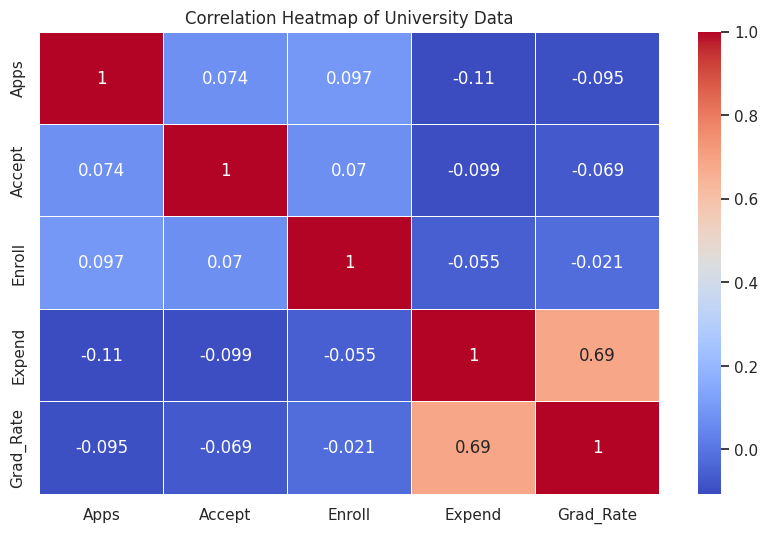

In [57]:
# TODO: Create a correlation heatmap
# Fill in the missing function names.
# Question 1: Which pandas method selects only numerical columns?
# Fill in: df.________(include=[np.number])
#
# Question 2: Which pandas method calculates correlations between columns?
# Fill in: numeric_df.________() 
#
# Question 3: Which seaborn function creates a heatmap?
# Fill in: sns.________()?

# 1. Select only numerical columns
numeric_df = df.select_dtypes(include=[np.number])

# 2. Calculate Correlation
corr_matrix = numeric_df.corr()

# 3. Plot Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of University Data')
plt.show()

### Automated Discovery: Pairplots

#### The Problem with Traditional Scatter Plots

Imagine you have 5 numerical variables. How many scatter plots would you need to compare all pairs?

**Answer:** 5 × 4 / 2 = **10 scatter plots**

For 10 variables? **45 plots.** For 20 variables? **190 plots!**

This is unsustainable. You'd spend more time creating plots than understanding your data.

#### The Solution: Pairplot (All-in-One Visualisation)

A **pairplot** automatically creates a grid of scatter plots for every pair of variables. But here's the clever part: you can add a **third dimension** using colour (the `hue` argument) to reveal categorical patterns.

#### What a Pairplot Shows

In the grid:
- **Diagonal cells** — Histograms or density plots (distribution of each variable)
- **Off-diagonal cells** — Scatter plots (relationships between pairs)
- **Colour coding** — Different categories (e.g., Private vs Public) use different colours

This allows you to see not just *if* variables are related, but *if that relationship differs* by category.

### Real-World Insight

In our University data, a pairplot might reveal:
- Private schools (orange dots) cluster in the high-expenditure, high-graduation-rate region
- Public schools (blue dots) cluster differently, suggesting a different economic model
- The relationship between expenditure and graduation rate is visible across all schools, but the clusters are distinct



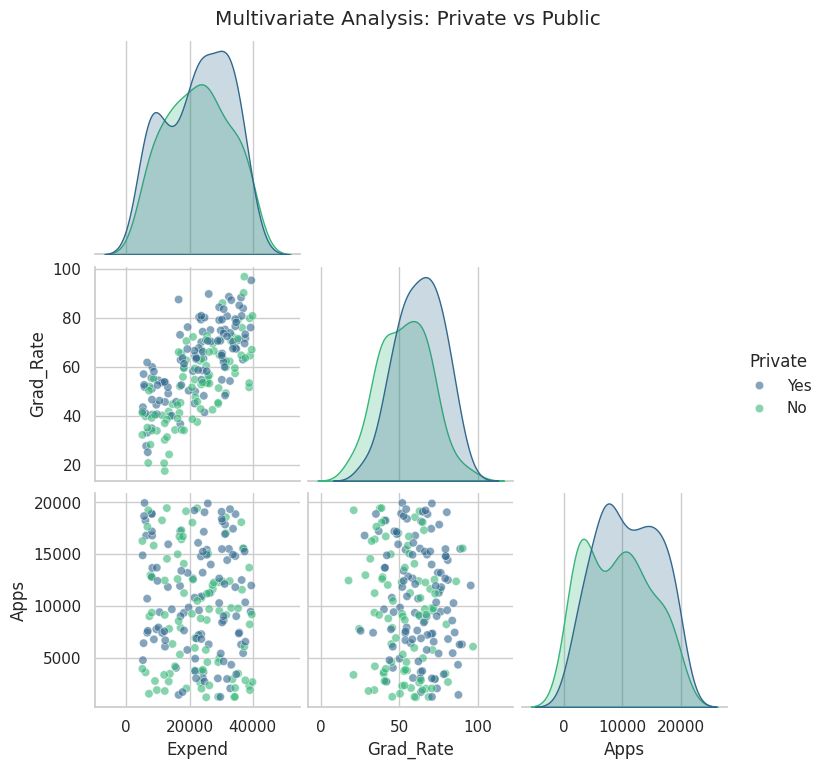

In [61]:
# Plotting a subset of columns to keep it readable
cols_of_interest = ['Expend', 'Grad_Rate', 'Apps']

sns.pairplot(
    df, 
    vars=cols_of_interest, 
    hue='Private',      # The "Third Dimension"
    palette='viridis',  # Colour scheme
    corner=True,        # Hides the upper triangle (redundant)
    plot_kws={'alpha': 0.6} # Transparency
)
plt.suptitle("Multivariate Analysis: Private vs Public", y=1.02)
plt.show()


### The Code: Step-by-Step

```python
cols_of_interest = ['Expend', 'Grad_Rate', 'Apps']
```
**Why?** With 6 variables, a pairplot would be 6×6 = 36 cells. Too crowded. We select 3 variables for readability.

```python
sns.pairplot(
    df,                          # The dataframe to plot
    vars=cols_of_interest,       # Only these columns are compared
    hue='Private',               # Colour-code by the 'Private' column
    palette='viridis',           # Colour scheme (blue → yellow)
    corner=True,                 # Only show lower triangle (reduces redundancy)
    plot_kws={'alpha': 0.6}      # Make points 60% opaque to show overlaps
)
```

**Key Parameters Explained:**

- `vars=cols_of_interest` — Specifies which numerical columns to include. Without this, all numerical columns are used.
  
- `hue='Private'` — This is the "third dimension." Points are coloured based on their value in the 'Private' column. Essential for discovering category-based patterns.
  
- `palette='viridis'` — Colour scheme. Options include 'viridis' (blue-yellow), 'husl', 'Set2', etc. Choose a colourblind-friendly palette for accessibility.
  
- `corner=True` — Removes the upper triangle of the grid. This is redundant because a scatter plot of (X, Y) is identical to (Y, X), just rotated. Saves space and processing time.
  
- `plot_kws={'alpha': 0.6}` — "Alpha" is transparency. At 0.6, overlapping points create darker regions, revealing data density. Essential for spotting clusters.

```python
plt.suptitle("Multivariate Analysis: Private vs Public", y=1.02)
```
Adds a title to the entire figure. The `y=1.02` parameter positions it above the grid.

### Interpretation Tips

When you run this code, look for:
1. **Separation by colour** — Do the two categories occupy different regions of the scatter plot?
2. **Trend lines** — Do both categories show the same trend (slope), or different ones?
3. **Overlap regions** — Where do the colours mix? This reveals boundary cases.
4. **Clustering** — Are points tightly grouped (strong relationship) or scattered (weak relationship)?

---



### FacetGrid: The "Small Multiples" Approach

#### The Motivation: Does the Relationship Hold Across All Groups?

Imagine you've discovered a strong relationship between two variables. For example: "Universities that spend more on education have higher graduation rates."

But here's the critical question: **Does this relationship hold true for ALL types of universities?**

- Do Elite schools follow the same pattern as Non-Elite schools?
- Do Private schools follow the same pattern as Public schools?
- What if the relationship is strong for one category but weak or reversed for another?

A single scatter plot hides these group-specific nuances. This is where **FacetGrid** becomes essential.

#### The Strategy: "Small Multiples"

Instead of overlaying all groups in one plot (with colour coding), FacetGrid creates **separate mini-plots** for each combination of categories. This allows you to compare patterns side-by-side without visual clutter.

**Key Insight:** Your eyes are better at comparing separate panels than comparing colours within the same space.

#### Why This Matters

Consider three scenarios:

**Scenario A (No Interaction):**
- Private schools: Spend more, graduate more (steep slope)
- Public schools: Spend more, graduate more (same steep slope)
- **Conclusion:** Spending is universally beneficial. Sector doesn't matter.

**Scenario B (Interaction Effect):**
- Private schools: Spend more, graduate much more (very steep slope)
- Public schools: Spend more, graduate a little (shallow slope)
- **Conclusion:** Spending benefits private schools more. Investment strategy depends on sector.

**Scenario C (Opposite Effect):**
- Private schools: Spend more, graduate more (steep slope)
- Public schools: Spend more, graduate less (negative slope!)
- **Conclusion:** The opposite is true for each sector. This is hidden in a single plot.

A FacetGrid reveals all three scenarios immediately.


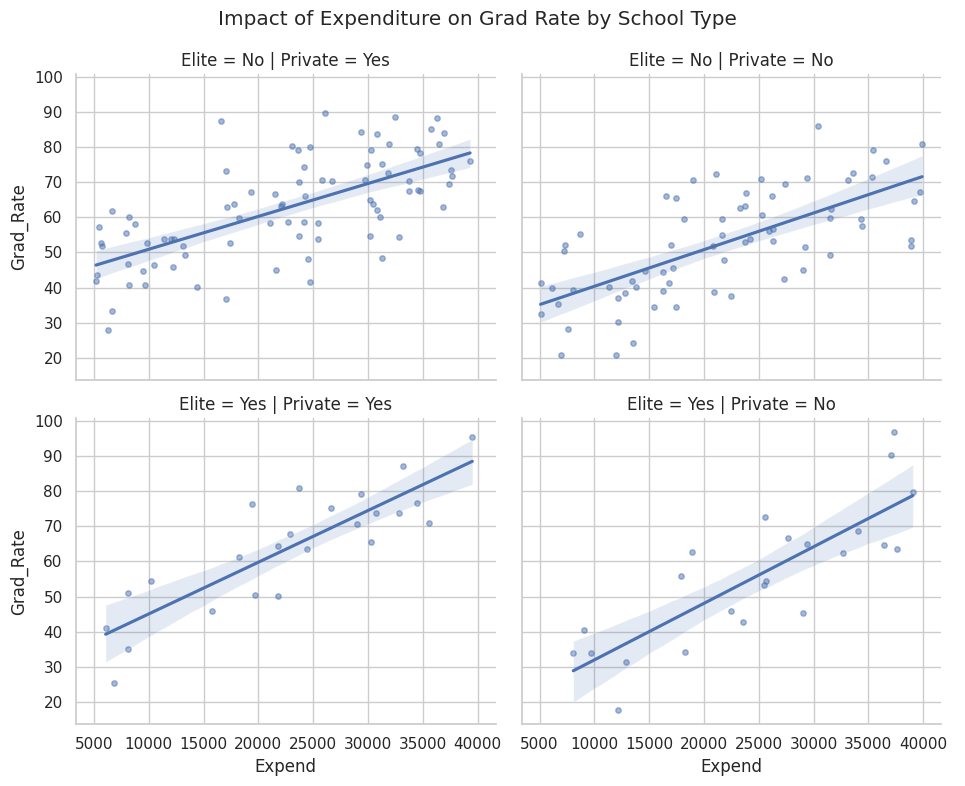

In [63]:
# Question: Does spending money (Expend) increase Grad Rate for BOTH Elite and Non-Elite schools?

g = sns.FacetGrid(df, col='Private', row='Elite', height=4, aspect=1.2)

# Map a plotting function to each grid
g.map(sns.regplot, 'Expend', 'Grad_Rate', scatter_kws={'s': 15, 'alpha':0.5})

g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Impact of Expenditure on Grad Rate by School Type')
plt.show()

### The Code: Step-by-Step

```python
g = sns.FacetGrid(
    df,                    # The dataframe
    col="Elite",           # Separate columns for Elite vs Non-Elite
    row="Private",         # Separate rows for Private vs Public
    height=4,              # Height of each subplot
    aspect=1.2             # Width-to-height ratio
)
```

**Parameter Breakdown:**

- `col="Elite"` — Creates separate columns (left-right separation). Elite=Yes in one column, Elite=No in another.
- `row="Private"` — Creates separate rows (top-bottom separation). Private=Yes at the top, Private=No at the bottom.
- Together, they create a **2x2 grid** (4 subplots total), showing all combinations of Elite/Private status.
- `height=4` — Each subplot is 4 inches tall. Adjust for readability.
- `aspect=1.2` — Each subplot is 1.2 times wider than it is tall, roughly square-ish.

```python
g.map(sns.regplot, "Expend", "Grad_Rate", scatter_kws={'s': 15, 'alpha':0.5})
```

- `g.map()` — Applies a plotting function to each subplot independently.
- `sns.regplot` — Scatter plot with a linear regression line. Perfect for seeing trends.
- `"Expend", "Grad_Rate"` — X-axis and Y-axis variables.
- `scatter_kws={'s': 15, 'alpha':0.5}` — Small dot size (15) and 50% transparency to reduce overplotting.

```python
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Impact of Expenditure on Grad Rate by School Type')
```

- `add_legend()` — Adds a legend explaining categories.
- `subplots_adjust()` — Reserves space for the title.
- `suptitle()` — Adds an overall title.

### Interpretation Tips

When you run this code, examine:

1. **Slope of regression lines** — Are the slopes similar across all four panels, or do they differ? Different slopes suggest an interaction effect.

2. **Scatter pattern** — Are points tightly clustered (strong relationship) in all panels, or only some?

3. **Outliers** — Do certain school types have extreme outliers that dominate one panel?

4. **Intercept differences** — Even if slopes are the same, do some panels start higher (better graduation rates at lower spending)?

5. **Data density** — Do all four panels have similar numbers of points, or is one category dominant?

### Real-World Application

This visualisation answers questions like:

- Should we increase spending across all school types, or focus on specific sectors?
- Does being an Elite school guarantee success, or does it depend on spending?
- Are there "efficient" school types (high graduation despite lower spending)?

### Visualising statistical distributions: Violin and Box Plots

#### The Motivation: Beyond measuring central tendencies

You've created scatter plots and explored relationships. But here's a critical gap: **What does the full distribution of data look like?**

For example, if you know the average graduation rate is 70%, that tells you almost nothing about:
- Are most universities clustered around 70%, or spread widely?
- Are there outliers at 25% or 95%?
- Is the distribution symmetric (bell-shaped) or skewed (lopsided)?
- Do private universities have a fundamentally different distribution than public ones?

A single number (the mean) hides all this complexity. Visualising distributions reveals the true "shape" of your data.

#### Understanding data shape

Before learning the plots, understand what shape means:

**Normal Distribution (Bell Curve):**
- Most data clustered in the middle
- Symmetric tails on both sides
- Common in nature, but rare in real datasets
- [Visual Example: Normal Distribution](https://en.wikipedia.org/wiki/Normal_distribution#/media/File:Normal_Distribution_PDF.svg)

**Bimodal Distribution:**
- Two peaks instead of one
- Suggests two distinct subgroups in your data
- Example: Private universities (high graduation) and public universities (lower graduation) mixed in one variable
- [Visual Example: Bimodal Distribution](https://math.stackexchange.com/questions/2149570/how-to-generate-sample-from-bimodal-distribution)

**Skewed Distribution:**
- Tail extends to one side
- Right-skewed: Long tail to the right (a few very high values)
- Left-skewed: Long tail to the left (a few very low values)
- [Visual Example: Right-Skewed Distribution](https://alanarnholt.github.io/PDS-Bookdown2/skewed-right-distributions.html)
- [Visual Example: Left-Skewed Distribution](https://statacumen.com/teach/S4R/PDS_book/skewed-left-distributions.html)

**Uniform Distribution:**
- Flat across all values
- Rare in real data, more common in simulated data
- [Visual Example: Uniform Distribution](https://en.wikipedia.org/wiki/Uniform_distribution_(continuous)#/media/File:Uniform_Distribution_PDF_SVG.svg)

#### The Box plot - summarising the distribution

A **box plot** shows five key statistics:
1. **Minimum (bottom whisker)** — Lowest value (excluding outliers)
2. **Q1 (bottom of box)** — 25th percentile (first quarter of data)
3. **Median (line in box)** — 50th percentile (middle value)
4. **Q3 (top of box)** — 75th percentile (third quarter of data)
5. **Maximum (top whisker)** — Highest value (excluding outliers)
6. **Outliers (dots)** — Unusual values beyond the whiskers

**Key Insight:** The box contains the "middle 50%" of your data. A tall box means values are spread out; a short box means values are tightly clustered.

#### The Violin Plot: Revealing Hidden Multimodality

A **violin plot** shows the full probability density (the entire shape of the distribution), not just five summary statistics.

**Why it's called "violin":**
The plot is symmetric around the x-axis, creating a violin-like outline. Wide sections indicate where data is dense; narrow sections indicate where data is sparse.

**Advantage over box plots:**
- **Box plots hide bimodality.** You might have two distinct peaks, but a box plot shows only summary statistics.
- **Violin plots reveal it immediately.** Two peaks appear as a bulged shape in the middle of the violin.

**Example:**
Two universities could have identical median graduation rates, but:
- One has a "U-shaped" distribution (many low-performers and many high-performers, few in the middle)
- One has a bell curve (most students perform near the average)

A box plot shows the same median for both. A violin plot reveals the completely different distributions instantly.

### Comparison: When to Use Each

| Feature | Box Plot | Violin Plot |
|---------|----------|-------------|
| **Simplicity** | Very simple to read | More complex visually |
| **Summary stats** | Shows 5-point summary | Shows full density |
| **Bimodal detection** | Misses it | Reveals it clearly |
| **Small datasets** | Good | Can be noisy |
| **Large datasets** | Limited detail | Excellent |
| **Publication-ready** | Widely accepted | Growing acceptance |



In [71]:
data['Grad_Rate'].max()

np.float64(99.8615569554306)

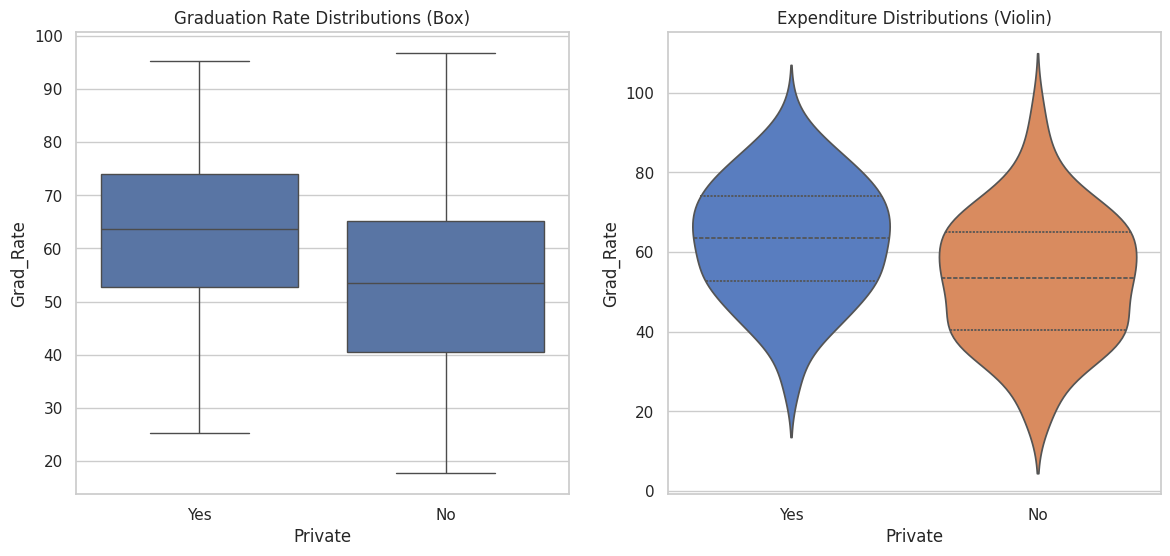

In [69]:
# Create subplots for Box and Violin plots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box Plot
sns.boxplot(data=df, x='Private', y='Grad_Rate', ax=axes[0])
axes[0].set_title("Graduation Rate Distributions (Box)")

# Violin Plot with Split
# We create a dummy variable 'All' just to show the split capability if we had another category
sns.violinplot(data=df, x='Private', y='Grad_Rate', ax=axes[1], inner="quartile", palette="muted", hue='Private')
axes[1].set_title("Expenditure Distributions (Violin)")

plt.show()

### The Code: Step-by-Step

```python
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
```
Creates a figure with 2 subplots side-by-side. Allows direct comparison.

```python
sns.boxplot(data=df, x='Private', y='Grad_Rate', ax=axes[0])
axes[0].set_title("Graduation Rate Distributions (Box)")
```

**Box Plot Parameters:**
- `data=df` — The dataframe
- `x='Private'` — Categorical variable on x-axis (Yes/No)
- `y='Grad_Rate'` — Numerical variable on y-axis
- `ax=axes[0]` — Plot on the first subplot

**Interpretation:**
Look at the height of the boxes and the positions of the median lines. A box plot showing the same median but different box heights would indicate different distributions even if the centre is the same.

```python
sns.violinplot(
    data=df,
    x='Private',
    y='Expend',
    ax=axes[1],
    inner="quartile",     # Show Q1, median, Q3 lines inside the violin
    palette="muted"       # Subtle colours
)
axes[1].set_title("Expenditure Distributions (Violin)")
```

**Violin Plot Parameters:**
- `inner="quartile"` — Overlays box plot quartile lines inside the violin for quick reference
- `palette="muted"` — Uses soft, colourblind-friendly colours
- Other parameters identical to box plot

**Why `inner="quartile"`?**
This combines the best of both worlds: the detailed shape of a violin with the summary statistics of a box plot.

### Interpretation Tips

When you run this code, look for:

1. **Median position** — Is it closer to Q1 or Q3? This indicates skewness.

2. **Box height** — Tall box = dispersed data. Short box = tightly clustered data.

3. **Whisker length** — Long whiskers suggest outliers. Outliers appear as individual dots.

4. **Violin width variations** — Wider sections indicate data density. Narrow sections are sparse regions. Multiple bulges suggest distinct subgroups.

5. **Comparison across categories** — Do private and public universities have fundamentally different distributions, or are they similar?

6. **Bimodality detection** — Look for "pinches" in the violin (narrow waists). These suggest two distinct peaks in the distribution.

### Real-World Application

This visualisation answers questions like:

- Which university type (private vs public) has more consistent graduation rates?
- Are there outlier universities with unusually high or low graduation rates?
- Is spending evenly distributed across all universities, or are there stark disparities?
- Do elite schools have more uniform spending patterns, or wider variation?

## Exercise: The "Auction House" Investigation

**Scenario:** You are analyzing the `auction_data` below. 

**Hypothesis:** The auction house believes that "Gadgets" sold on weekends (`is_weekend=True`) fetch higher prices than those sold on weekdays, but this trend doesn't apply to "Antiques".

**Task:**
1.  Create a `FacetGrid` or `lmplot` (Linear Model plot).
2.  Put `Bids` on the x-axis and `Final_Price` on the y-axis.
3.  Use columns (`col`) to separate "Category".
4.  Use color (`hue`) to separate "Weekend" vs "Weekday".
5.  **Answer:** Is the hypothesis true?

In [72]:
# Setup Data for Exercise
auction_df = pd.DataFrame({
    'Category': np.random.choice(['Gadgets', 'Antiques'], 200),
    'Bids': np.random.randint(1, 50, 200),
    'Final_Price': np.random.randint(10, 500, 200),
    'Is_Weekend': np.random.choice([True, False], 200)
})

# Making the hypothesis true for the sake of the exercise
mask = (auction_df['Category'] == 'Gadgets') & (auction_df['Is_Weekend'] == True)
auction_df.loc[mask, 'Final_Price'] += 100

display(auction_df.head())

,Category,Bids,Final_Price,Is_Weekend
0,Gadgets,35,553,True
1,Gadgets,28,21,False
2,Gadgets,7,397,True
3,Gadgets,32,237,True
4,Gadgets,11,205,True


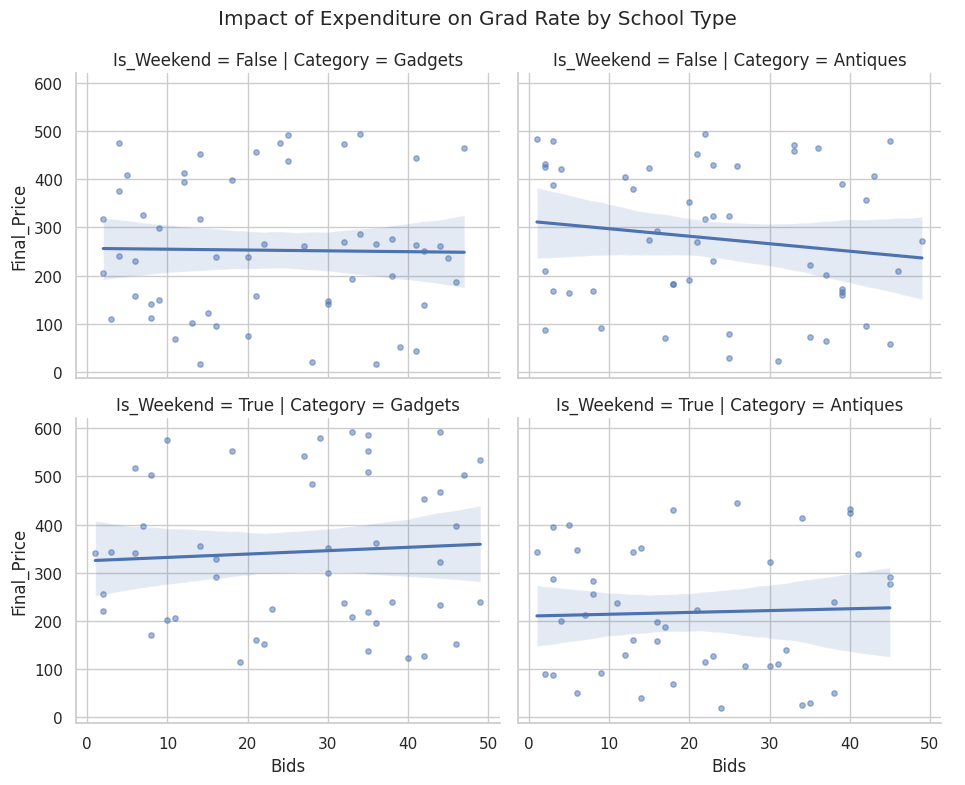

In [76]:
#The auction house believes that "Gadgets" sold on weekends (`is_weekend=True`) fetch higher prices than those sold on weekdays, but this trend doesn't apply to "Antiques".
g = sns.FacetGrid(auction_df, col='Category', row='Is_Weekend', height=4, aspect=1.2)

# Map a plotting function to each grid
g.map(sns.regplot, 'Bids', 'Final_Price', scatter_kws={'s': 15, 'alpha':0.5})

g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Impact of Expenditure on Grad Rate by School Type')
plt.show()

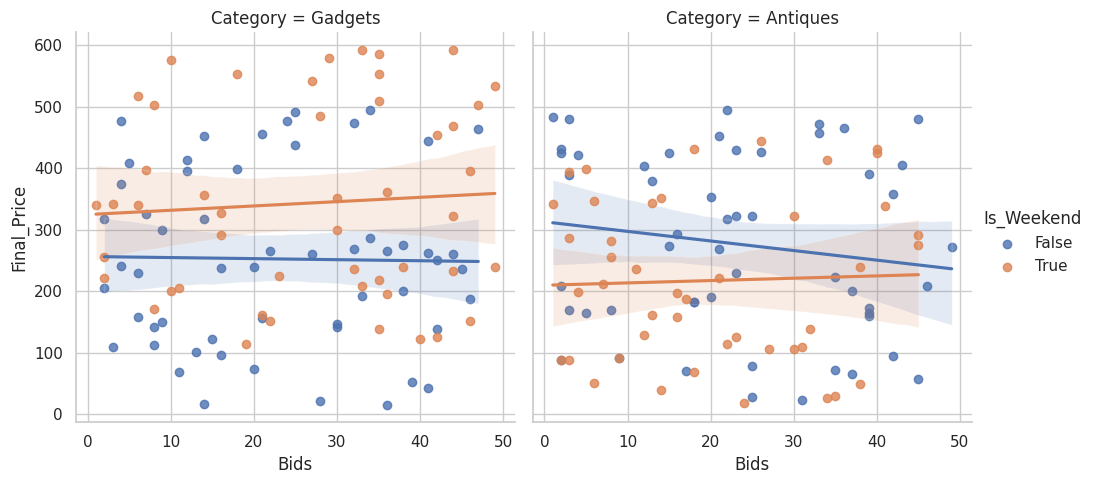

In [86]:
# YOUR CODE HERE

sns.lmplot(
    data=auction_df,
    x='Bids',
    y='Final_Price',
    hue='Is_Weekend',
    col='Category'
)